In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Create Environment (creates world)
env = gym.make("CartPole-v1")

In [3]:
#Reset Environment (start new episodes & return state = 4 values(cart position, velocity, angle, angular velocity))
state, _ = env.reset()
print("Initial State:", state)

Initial State: [-0.03164608 -0.04877903 -0.03212256 -0.0412797 ]


In [4]:
#Take Random Actions (First interaction)
for _ in range(5):
    action = env.action_space.sample()
    next_state, reward, done, truncated, _ = env.step(action)
    
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward:", reward)
    print("Done:", done)
    print("------")

Action: 0
Next State: [-0.03262166 -0.24342598 -0.03294815  0.24109769]
Reward: 1.0
Done: False
------
Action: 1
Next State: [-0.03749018 -0.04784924 -0.0281262  -0.06179319]
Reward: 1.0
Done: False
------
Action: 1
Next State: [-0.03844716  0.14766444 -0.02936206 -0.36321574]
Reward: 1.0
Done: False
------
Action: 1
Next State: [-0.03549387  0.34319115 -0.03662637 -0.6650106 ]
Reward: 1.0
Done: False
------
Action: 0
Next State: [-0.02863005  0.14859729 -0.04992659 -0.3840813 ]
Reward: 1.0
Done: False
------


In [5]:
#Run One Full Episode
state, _ = env.reset()

total_reward = 0

for step in range(1000):
    action = env.action_space.sample()
    state, reward, done, truncated, _ = env.step(action)
    
    total_reward += reward
    
    if done or truncated:
        break

print("Total Reward:", total_reward)

Total Reward: 36.0


In [6]:
#Run Multiple Episodes
episodes = 20
rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    
    for step in range(1000):
        action = env.action_space.sample()
        state, reward, done, truncated, _ = env.step(action)
        
        total_reward += reward
        
        if done or truncated:
            break
    
    rewards.append(total_reward)

print(rewards)

[13.0, 24.0, 10.0, 19.0, 14.0, 33.0, 15.0, 27.0, 36.0, 24.0, 13.0, 20.0, 30.0, 11.0, 39.0, 22.0, 15.0, 34.0, 16.0, 21.0]


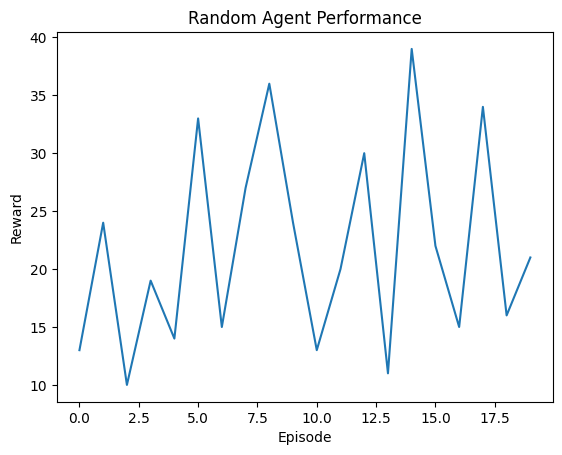

In [7]:
#Results
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random Agent Performance")
plt.show()

In [8]:
#Discretization (convert values to bins)

# Number of buckets for each state variable
n_bins = (10, 10, 10, 10)

# Define upper and lower bounds
upper_bounds = [2.4, 3.0, 0.5, 2.0]
lower_bounds = [-2.4, -3.0, -0.5, -2.0]

In [9]:
#Discretization Function
def discretize(state):
    ratios = [(state[i] - lower_bounds[i]) / (upper_bounds[i] - lower_bounds[i]) for i in range(len(state))]
    
    new_state = [int(round((n_bins[i] - 1) * ratios[i])) for i in range(len(state))]
    
    new_state = [min(n_bins[i] - 1, max(0, new_state[i])) for i in range(len(state))]
    
    return tuple(new_state)

In [10]:
#Test Discretization

state, _ = env.reset()

discrete_state = discretize(state)

print("Original:", state)
print("Discrete:", discrete_state)

Original: [-0.04776405 -0.00863739  0.02774044 -0.01862944]
Discrete: (4, 4, 5, 4)


In [11]:
#Create Q-table
q_table = np.zeros(n_bins + (env.action_space.n,))

In [12]:
#Hyperparameters
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 5000

In [13]:
#Q-learning Training Loop
rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    discrete_state = discretize(state)
    
    total_reward = 0
    
    for step in range(1000):
        
        # ε-greedy policy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[discrete_state])
        
        next_state, reward, done, truncated, _ = env.step(action)
        next_discrete_state = discretize(next_state)
        
        # Q-learning update
        best_future_q = np.max(q_table[next_discrete_state])
        
        q_table[discrete_state + (action,)] += learning_rate * (
            reward + discount_factor * best_future_q - q_table[discrete_state + (action,)]
        )
        
        discrete_state = next_discrete_state
        total_reward += reward
        
        if done or truncated:
            break
    
    # decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    rewards.append(total_reward)

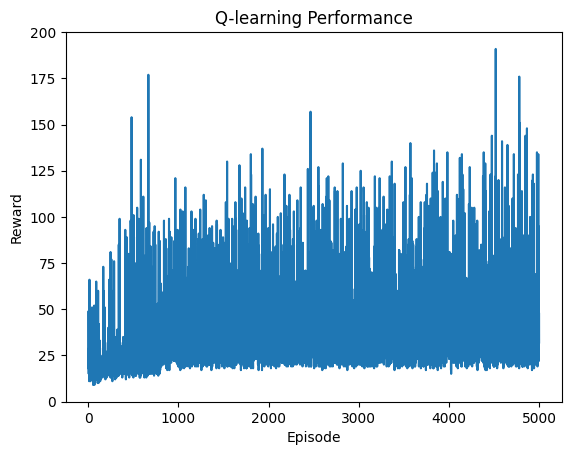

In [14]:
#Plot Learning

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-learning Performance")
plt.show()

In [15]:
#Moving Average Function
def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

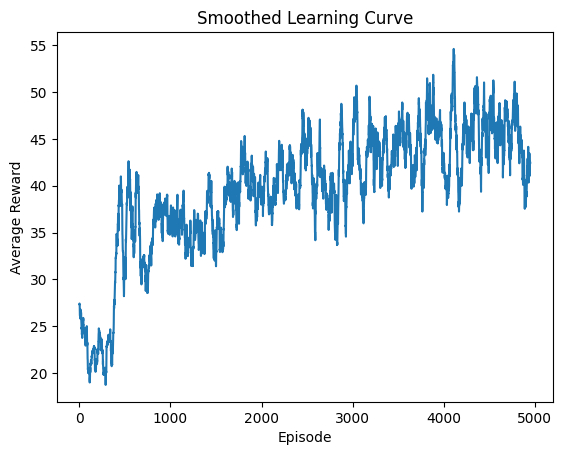

In [16]:
#Plot Smoothed Curve
smoothed_rewards = moving_average(rewards)

plt.plot(smoothed_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Smoothed Learning Curve")
plt.show()

In [17]:
#Better Discretization (Improved Bins)
n_bins = (8, 8, 12, 12)  # more focus on angle
upper_bounds = [2.4, 3.0, 0.418, 2.0]
lower_bounds = [-2.4, -3.0, -0.418, -2.0]

In [18]:
q_table = np.zeros(n_bins + (env.action_space.n,))

In [19]:
#Hyperparameters
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.999
min_epsilon = 0.01
episodes = 5000

In [20]:
rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    discrete_state = discretize(state)
    
    total_reward = 0
    
    for step in range(1000):
        
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[discrete_state])
        
        next_state, reward, done, truncated, _ = env.step(action)
        next_discrete_state = discretize(next_state)
        
        # FIXED
        best_future_q = np.max(q_table[next_discrete_state])
        
        q_table[discrete_state + (action,)] += learning_rate * (
            reward + discount_factor * best_future_q - q_table[discrete_state + (action,)]
        )
        
        discrete_state = next_discrete_state
        total_reward += reward
        
        if done or truncated:
            break
    
    rewards.append(total_reward)
    
    if episode % 100 == 0:
        print(f"Episode: {episode}, Avg Reward: {np.mean(rewards[-100:])}, Epsilon: {epsilon:.3f}")
    
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

Episode: 0, Avg Reward: 12.0, Epsilon: 1.000
Episode: 100, Avg Reward: 21.85, Epsilon: 0.905
Episode: 200, Avg Reward: 22.23, Epsilon: 0.819
Episode: 300, Avg Reward: 23.3, Epsilon: 0.741
Episode: 400, Avg Reward: 23.15, Epsilon: 0.670
Episode: 500, Avg Reward: 22.57, Epsilon: 0.606
Episode: 600, Avg Reward: 26.71, Epsilon: 0.549
Episode: 700, Avg Reward: 34.06, Epsilon: 0.496
Episode: 800, Avg Reward: 35.21, Epsilon: 0.449
Episode: 900, Avg Reward: 41.43, Epsilon: 0.406
Episode: 1000, Avg Reward: 46.22, Epsilon: 0.368
Episode: 1100, Avg Reward: 60.85, Epsilon: 0.333
Episode: 1200, Avg Reward: 73.08, Epsilon: 0.301
Episode: 1300, Avg Reward: 92.61, Epsilon: 0.272
Episode: 1400, Avg Reward: 75.65, Epsilon: 0.246
Episode: 1500, Avg Reward: 113.04, Epsilon: 0.223
Episode: 1600, Avg Reward: 79.46, Epsilon: 0.202
Episode: 1700, Avg Reward: 129.88, Epsilon: 0.183
Episode: 1800, Avg Reward: 102.66, Epsilon: 0.165
Episode: 1900, Avg Reward: 111.02, Epsilon: 0.149
Episode: 2000, Avg Reward: 193

In [21]:
def evaluate_agent(episodes=10):
    eval_rewards = []
    
    for _ in range(episodes):
        state, _ = env.reset()
        discrete_state = discretize(state)
        total_reward = 0
        
        for step in range(1000):
            action = np.argmax(q_table[discrete_state])
            
            state, reward, done, truncated, _ = env.step(action)
            discrete_state = discretize(state)
            
            total_reward += reward
            
            if done or truncated:
                break
        
        eval_rewards.append(total_reward)
    
    return np.mean(eval_rewards)

In [22]:
print("Average Reward:", evaluate_agent())

Average Reward: 500.0


In [41]:
#Save Model
np.save("q_table.npy", q_table)

In [23]:
#Create Render ENvironment
env_render = gym.make("CartPole-v1", render_mode="human")

In [24]:
import subprocess
import sys

#Run trained Agent
subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium[classic-control]"])
discrete_state = discretize(state)

total_reward = 0

for step in range(1000):
    
    # No exploration → pure learned policy
    action = np.argmax(q_table[discrete_state])
    
    state, _ = env_render.reset()
    discrete_state = discretize(state)
    
    total_reward += reward
    
    if done or truncated:
        break

print("Total Reward:", total_reward)

env_render.close()

Total Reward: 1.0


In [25]:
#Record Video 
from gymnasium.wrappers import RecordVideo

state, _ = env.reset()

env_video = RecordVideo(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda x: True
)

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at e:\Pyhton code\Machine Learning\Reinforcement Learning\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [26]:
#Run and save video
state, _ = env_video.reset()
discrete_state = discretize(state)

for step in range(1000):
    action = np.argmax(q_table[discrete_state])
    
    state, reward, done, truncated, _ = env_video.step(action)
    discrete_state = discretize(state)
    
    if done or truncated:
        break

env_video.close()

Apply DQN 

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

In [28]:
#Environment Setup
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]   # 4
action_size = env.action_space.n              # 2

print(state_size, action_size)

4 2


In [29]:
#Build Neural Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        
        self.fc1 = nn.Linear(state_size, 24)
        self.fc2 = nn.Linear(24, 24)
        self.fc3 = nn.Linear(24, action_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [30]:
#Initialize Model
model = DQN(state_size, action_size)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [31]:
#Replay Memory
memory = deque(maxlen=2000)

In [32]:
#Store Experience
def store_experience(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

In [33]:
#Action Selection
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return random.randrange(action_size)
    
    state_tensor = torch.FloatTensor(state)
    q_values = model(state_tensor)
    
    return torch.argmax(q_values).item()

In [34]:
#Training step
def train_model(batch_size=32):
    if len(memory) < 1000:
        return
    
    batch = random.sample(memory, batch_size)
    
    states, actions, rewards, next_states, dones = zip(*batch)
    
    states = torch.FloatTensor(states)
    next_states = torch.FloatTensor(next_states)
    actions = torch.LongTensor(actions)
    rewards = torch.FloatTensor(rewards)
    dones = torch.FloatTensor(dones)
    
    # Current Q
    q_values = model(states)
    current_q = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
    
    # Target Q (using target network 🔥)
    next_q = target_model(next_states).max(1)[0]
    target_q = rewards + (1 - dones) * 0.99 * next_q
    
    loss = loss_fn(current_q, target_q.detach())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [35]:
def update_target():
    target_model.load_state_dict(model.state_dict())

In [36]:
target_model = DQN(state_size, action_size)
target_model.load_state_dict(model.state_dict())
target_model.eval()

DQN(
  (fc1): Linear(in_features=4, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=24, bias=True)
  (fc3): Linear(in_features=24, out_features=2, bias=True)
)

In [37]:
#Full training loop
episodes = 1000
epsilon = 1.0
epsilon_decay = 0.999
min_epsilon = 0.01

rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    
    for step in range(1000):
        
        action = choose_action(state, epsilon)
        
        next_state, reward, done, truncated, _ = env.step(action)
        
        store_experience(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        
        train_model()
        
        if done or truncated:
            break
    
    rewards.append(total_reward)
    
    # update target network every 10 episodes
    if episode % 50 == 0:
        update_target()
    
    # decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    # logging
    if episode % 10 == 0:
        print(f"Episode: {episode}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

Episode: 0, Reward: 18.0, Epsilon: 0.999
Episode: 10, Reward: 21.0, Epsilon: 0.989
Episode: 20, Reward: 9.0, Epsilon: 0.979
Episode: 30, Reward: 23.0, Epsilon: 0.969
Episode: 40, Reward: 12.0, Epsilon: 0.960
Episode: 50, Reward: 46.0, Epsilon: 0.950


C:\Users\SUYASH\AppData\Local\Temp\ipykernel_20116\634872370.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  states = torch.FloatTensor(states)


Episode: 60, Reward: 14.0, Epsilon: 0.941
Episode: 70, Reward: 14.0, Epsilon: 0.931
Episode: 80, Reward: 22.0, Epsilon: 0.922
Episode: 90, Reward: 26.0, Epsilon: 0.913
Episode: 100, Reward: 11.0, Epsilon: 0.904
Episode: 110, Reward: 19.0, Epsilon: 0.895
Episode: 120, Reward: 18.0, Epsilon: 0.886
Episode: 130, Reward: 17.0, Epsilon: 0.877
Episode: 140, Reward: 34.0, Epsilon: 0.868
Episode: 150, Reward: 14.0, Epsilon: 0.860
Episode: 160, Reward: 89.0, Epsilon: 0.851
Episode: 170, Reward: 50.0, Epsilon: 0.843
Episode: 180, Reward: 11.0, Epsilon: 0.834
Episode: 190, Reward: 101.0, Epsilon: 0.826
Episode: 200, Reward: 29.0, Epsilon: 0.818
Episode: 210, Reward: 17.0, Epsilon: 0.810
Episode: 220, Reward: 12.0, Epsilon: 0.802
Episode: 230, Reward: 17.0, Epsilon: 0.794
Episode: 240, Reward: 34.0, Epsilon: 0.786
Episode: 250, Reward: 13.0, Epsilon: 0.778
Episode: 260, Reward: 164.0, Epsilon: 0.770
Episode: 270, Reward: 42.0, Epsilon: 0.763
Episode: 280, Reward: 17.0, Epsilon: 0.755
Episode: 290,

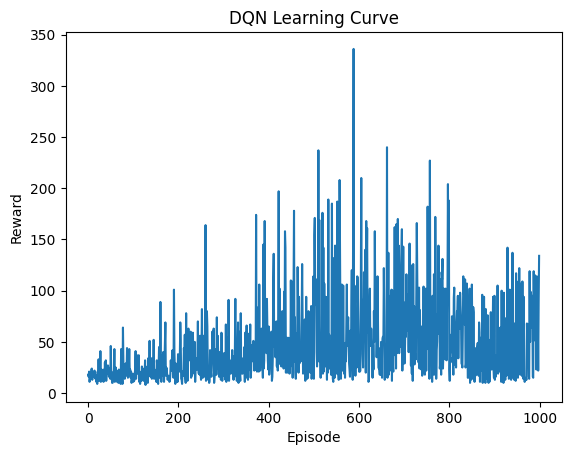

In [38]:
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Learning Curve")
plt.show()

In [39]:
def evaluate_dqn(episodes=10):
    scores = []
    
    for _ in range(episodes):
        state, _ = env.reset()
        total = 0
        
        for _ in range(1000):
            state_tensor = torch.FloatTensor(state)
            action = torch.argmax(model(state_tensor)).item()
            
            state, reward, done, truncated, _ = env.step(action)
            total += reward
            
            if done or truncated:
                break
        
        scores.append(total)
    
    return np.mean(scores)

print("Average Score:", evaluate_dqn())

Average Score: 97.1


In [42]:
#save DQN Model
torch.save(model.state_dict(), "dqn_cartpole.pth")

In [40]:
action = torch.argmax(model(torch.FloatTensor(state))).item()